# Spread Option Pricing

A spread option pays the difference between two asset prices at maturity. For a European call with strike $K$:

$$V = e^{-rT}\,\mathbb{E}\!\left[\max(S_1(T) - S_2(T) - K,\; 0)\right]$$

where $S_1$ and $S_2$ follow correlated geometric Brownian motions with correlation $\rho$.

This notebook prices spread options with three methods:

- **Kirk's approximation** -- fast analytical formula (built-in C++)
- **Modified Kirk** -- pure Python extension with skew correction for high correlation
- **Monte Carlo** -- simulation benchmark via `MCEuropeanBasketEngine`

In [1]:
import pyquantlib as ql
from pyquantlib.extensions import ModifiedKirkEngine
import numpy as np
import matplotlib.pyplot as plt

## Market Setup

Market data is wrapped in `SimpleQuote` objects so that bumping a value automatically
propagates through the entire pricing chain, enabling bump-and-reprice Greeks.

In [2]:
today = ql.Date(15, 1, 2025)
ql.Settings.instance().evaluationDate = today
dc = ql.Actual365Fixed()
cal = ql.NullCalendar()

# Mutable market quotes
spot1_q = ql.SimpleQuote(100.0)
spot2_q = ql.SimpleQuote(100.0)
vol1_q = ql.SimpleQuote(0.30)
vol2_q = ql.SimpleQuote(0.20)
rate_q = ql.SimpleQuote(0.05)

# Term structures linked to quotes
rate_ts = ql.FlatForward(today, ql.QuoteHandle(rate_q), dc)
div_ts = ql.FlatForward(today, 0.0, dc)
rate_h = ql.YieldTermStructureHandle(rate_ts)
div_h = ql.YieldTermStructureHandle(div_ts)


def make_process(spot_quote, vol_quote):
    vol_ts = ql.BlackConstantVol(today, cal, ql.QuoteHandle(vol_quote), dc)
    return ql.GeneralizedBlackScholesProcess(
        ql.QuoteHandle(spot_quote), div_h, rate_h,
        ql.BlackVolTermStructureHandle(vol_ts),
    )


process1 = make_process(spot1_q, vol1_q)
process2 = make_process(spot2_q, vol2_q)

# Spread call: max(S1 - S2 - K, 0)
K = 5.0
T = 1.0
maturity = today + ql.Period(int(T * 365), ql.Days)
payoff = ql.PlainVanillaPayoff(ql.OptionType.Call, K)
option = ql.BasketOption(
    ql.SpreadBasketPayoff(payoff), ql.EuropeanExercise(maturity)
)

print(f"S1 = {spot1_q.value()}, S2 = {spot2_q.value()}")
print(f"sigma1 = {vol1_q.value():.0%}, sigma2 = {vol2_q.value():.0%}")
print(f"r = {rate_q.value():.0%}, K = {K}, T = {T}y")

S1 = 100.0, S2 = 100.0
sigma1 = 30%, sigma2 = 20%
r = 5%, K = 5.0, T = 1.0y


## Pricing with Three Methods

**Kirk** reduces the two-asset spread to a single Black-Scholes call with effective volatility
$\sigma_K = \sqrt{\sigma_1^2 - 2\rho\sigma_1\sigma_2 w + (\sigma_2 w)^2}$
where $w = F_2 / (F_2 + K)$. Fast but loses accuracy as $\rho \to 1$.

**Modified Kirk** (Alos & Leon, 2015) adds a skew correction
$\sigma_{\text{MK}} = \sigma_K + \beta\,(\ln F_1 - \ln K_{\text{eff}})$
that keeps errors bounded across all correlations. Implemented as a pure Python extension
subclassing `SpreadBlackScholesVanillaEngine`.

**Monte Carlo** simulates correlated GBM paths via `MCEuropeanBasketEngine`.

In [3]:
rho = 0.90

# Kirk (C++)
kirk = ql.KirkEngine(process1, process2, rho)

# Modified Kirk (Python extension)
mod_kirk = ModifiedKirkEngine(process1, process2, rho)

# Monte Carlo
corr_matrix = ql.Matrix(2, 2)
corr_matrix[0][0] = corr_matrix[1][1] = 1.0
corr_matrix[0][1] = corr_matrix[1][0] = rho
proc_array = ql.StochasticProcessArray([process1, process2], corr_matrix)
mc = ql.MCEuropeanBasketEngine(
    proc_array, timeSteps=1, requiredSamples=500_000, seed=42
)

print(f"rho = {rho}\n")
for name, engine in [("Kirk", kirk), ("Modified Kirk", mod_kirk), ("Monte Carlo", mc)]:
    option.setPricingEngine(engine)
    print(f"  {name:15s}  NPV = {option.NPV():.4f}")

rho = 0.9

  Kirk             NPV = 4.1429
  Modified Kirk    NPV = 4.1401
  Monte Carlo      NPV = 4.1367


## Correlation Sensitivity

Correlation is the dominant risk factor for spread options. As $\rho \to 1$, the spread
variance vanishes and Kirk's flat-vol assumption breaks down. The right panel shows how
Kirk's pricing error grows at high correlation while Modified Kirk stays bounded.

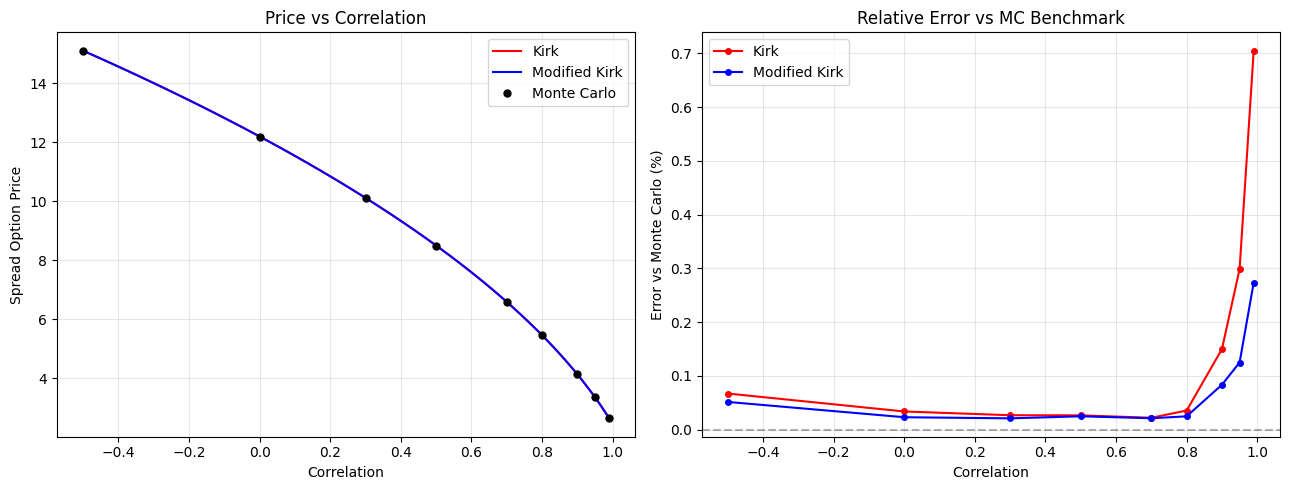

In [4]:
rho_range = np.linspace(-0.50, 0.99, 60)
rho_mc_pts = [-0.5, 0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

kirk_npvs, mk_npvs = [], []

for r in rho_range:
    kirk = ql.KirkEngine(process1, process2, r)
    mod_kirk = ModifiedKirkEngine(process1, process2, r)
    option.setPricingEngine(kirk)
    kirk_npvs.append(option.NPV())
    option.setPricingEngine(mod_kirk)
    mk_npvs.append(option.NPV())

# MC benchmark + analytical prices at the same points
mc_npvs, kirk_at_mc, mk_at_mc = [], [], []

for r in rho_mc_pts:
    kirk = ql.KirkEngine(process1, process2, r)
    mod_kirk = ModifiedKirkEngine(process1, process2, r)
    option.setPricingEngine(kirk)
    kirk_at_mc.append(option.NPV())
    option.setPricingEngine(mod_kirk)
    mk_at_mc.append(option.NPV())

    cm = ql.Matrix(2, 2)
    cm[0][0] = cm[1][1] = 1.0
    cm[0][1] = cm[1][0] = r
    pa = ql.StochasticProcessArray([process1, process2], cm)
    option.setPricingEngine(
        ql.MCEuropeanBasketEngine(pa, timeSteps=1, requiredSamples=500_000, seed=42)
    )
    mc_npvs.append(option.NPV())

kirk_npvs = np.array(kirk_npvs)
mk_npvs = np.array(mk_npvs)
mc_npvs = np.array(mc_npvs)
kirk_at_mc = np.array(kirk_at_mc)
mk_at_mc = np.array(mk_at_mc)

kirk_err = (kirk_at_mc - mc_npvs) / mc_npvs * 100
mk_err = (mk_at_mc - mc_npvs) / mc_npvs * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(rho_range, kirk_npvs, "r-", lw=1.5, label="Kirk")
ax1.plot(rho_range, mk_npvs, "b-", lw=1.5, label="Modified Kirk")
ax1.plot(rho_mc_pts, mc_npvs, "ko", ms=5, label="Monte Carlo")
ax1.set_xlabel("Correlation")
ax1.set_ylabel("Spread Option Price")
ax1.set_title("Price vs Correlation")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rho_mc_pts, kirk_err, "r-o", lw=1.5, ms=4, label="Kirk")
ax2.plot(rho_mc_pts, mk_err, "b-o", lw=1.5, ms=4, label="Modified Kirk")
ax2.set_xlabel("Correlation")
ax2.set_ylabel("Error vs Monte Carlo (%)")
ax2.set_title("Relative Error vs MC Benchmark")
ax2.legend()
ax2.axhline(0, color="k", ls="--", alpha=0.3)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Risk Sensitivities

Greeks via central-difference bump-and-reprice. Since market data is linked through
`SimpleQuote` handles, bumping a quote automatically propagates through term structures,
processes, and engines.

In [5]:
mod_kirk = ModifiedKirkEngine(process1, process2, 0.90)
option.setPricingEngine(mod_kirk)


def central_diff(quote, bump):
    orig = quote.value()
    quote.setValue(orig + bump)
    v_up = option.NPV()
    quote.setValue(orig - bump)
    v_dn = option.NPV()
    quote.setValue(orig)
    return (v_up - v_dn) / (2 * bump)


def second_diff(quote, bump):
    orig = quote.value()
    v_mid = option.NPV()
    quote.setValue(orig + bump)
    v_up = option.NPV()
    quote.setValue(orig - bump)
    v_dn = option.NPV()
    quote.setValue(orig)
    return (v_up - 2 * v_mid + v_dn) / bump**2


delta1 = central_diff(spot1_q, 0.01)
delta2 = central_diff(spot2_q, 0.01)
gamma1 = second_diff(spot1_q, 0.50)
gamma2 = second_diff(spot2_q, 0.50)
vega1 = central_diff(vol1_q, 0.001) * 0.01  # per 1 vol point
vega2 = central_diff(vol2_q, 0.001) * 0.01

print("Greeks (Modified Kirk, rho = 0.90)")
print()
print(f"  {'':12s} {'Asset 1':>10s} {'Asset 2':>10s}")
print(f"  {'-' * 34}")
print(f"  {'Delta':12s} {delta1:>+10.4f} {delta2:>+10.4f}")
print(f"  {'Gamma':12s} {gamma1:>+10.6f} {gamma2:>+10.6f}")
print(f"  {'Vega (1pt)':12s} {vega1:>+10.4f} {vega2:>+10.4f}")

Greeks (Modified Kirk, rho = 0.90)

                  Asset 1    Asset 2
  ----------------------------------
  Delta           +0.4105    -0.3540
  Gamma         +0.025470  +0.023305
  Vega (1pt)      +0.3259    -0.1919


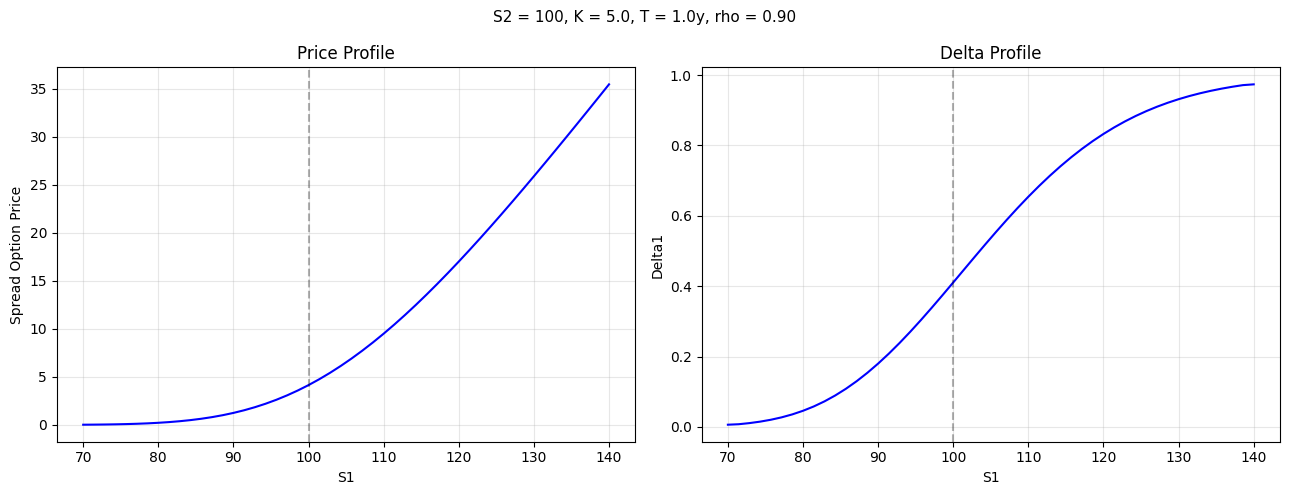

In [6]:
# Price and delta profiles as a function of S1
s1_values = np.linspace(70, 140, 50)
npv_profile = []

for s in s1_values:
    spot1_q.setValue(s)
    npv_profile.append(option.NPV())
spot1_q.setValue(100.0)

delta_profile = np.gradient(npv_profile, s1_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(s1_values, npv_profile, "b-", lw=1.5)
ax1.axvline(100, color="k", ls="--", alpha=0.3)
ax1.set_xlabel("S1")
ax1.set_ylabel("Spread Option Price")
ax1.set_title("Price Profile")
ax1.grid(True, alpha=0.3)

ax2.plot(s1_values, delta_profile, "b-", lw=1.5)
ax2.axvline(100, color="k", ls="--", alpha=0.3)
ax2.set_xlabel("S1")
ax2.set_ylabel("Delta1")
ax2.set_title("Delta Profile")
ax2.grid(True, alpha=0.3)

plt.suptitle(f"S2 = 100, K = {K}, T = {T}y, rho = 0.90", fontsize=11)
plt.tight_layout()
plt.show()

### References

1. Kirk, E. (1995). "Correlation in the energy markets." *Managing Energy Price Risk*.
2. Alos, E. & Leon, J.A. (2015). "On the short-time behavior of the implied volatility
   for jump-diffusion models with stochastic volatility."
   *Quantitative Finance*, 16(1), 31--42.